In [13]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl

from pathlib import Path
from scipy.fft import ifft

plt.rcParams["figure.figsize"] = (8,4)

DATASET_DIR = Path("datasets")

In [21]:
# ============================================================
# LOAD DATA
# ============================================================

with open(DATASET_DIR/"fd_data_s21_adi (1).pickle","rb") as f:
    s21 = pickle.load(f)


metadata = pd.DataFrame(metadata)

phantom_db = pd.read_csv(
    DATASET_DIR/"phantom_database.csv"
)

print("Loaded Successfully")

Loaded Successfully


In [22]:
# ============================================================
# DATASET OVERVIEW
# ============================================================

print("="*70)
print("UM-BMID DATASET OVERVIEW")
print("="*70)

n_scan, n_freq, n_channel = s21.shape

print(f"S21 Shape           : {s21.shape}")
print(f"Metadata Shape      : {metadata.shape}")
print(f"Phantom DB Shape    : {phantom_db.shape}")

print()

print(f"Number of Scans     : {n_scan}")
print(f"Frequency Samples   : {n_freq}")
print(f"Channels            : {n_channel}")

print()

print(f"Data Type           : {s21.dtype}")
print(f"Complex Dataset     : {np.iscomplexobj(s21)}")
print(f"Memory Usage        : {s21.nbytes/1024**2:.2f} MB")

print()

print("NaN Count           :", np.isnan(s21).sum())
print("Inf Count           :", np.isinf(s21).sum())

print()

print("Magnitude Statistics")
print("--------------------")
print(f"Min                 : {np.abs(s21).min():.4e}")
print(f"Mean                : {np.abs(s21).mean():.4e}")
print(f"Median              : {np.median(np.abs(s21)):.4e}")
print(f"Max                 : {np.abs(s21).max():.4e}")

print()

print("Real Statistics")
print("--------------------")
print(f"Min                 : {s21.real.min():.4e}")
print(f"Max                 : {s21.real.max():.4e}")

print()

print("Imag Statistics")
print("--------------------")
print(f"Min                 : {s21.imag.min():.4e}")
print(f"Max                 : {s21.imag.max():.4e}")

print("="*70)

UM-BMID DATASET OVERVIEW
S21 Shape           : (505, 1001, 72)
Metadata Shape      : (1301, 22)
Phantom DB Shape    : (63, 10)

Number of Scans     : 505
Frequency Samples   : 1001
Channels            : 72

Data Type           : complex128
Complex Dataset     : True
Memory Usage        : 555.36 MB

NaN Count           : 0
Inf Count           : 0

Magnitude Statistics
--------------------
Min                 : 5.1799e-07
Mean                : 5.0063e-03
Median              : 3.4221e-03
Max                 : 6.7302e-02

Real Statistics
--------------------
Min                 : -5.7477e-02
Max                 : 6.2627e-02

Imag Statistics
--------------------
Min                 : -6.5755e-02
Max                 : 5.7682e-02


In [23]:
# ============================================================
# METADATA AUDIT
# ============================================================

print(metadata.columns.tolist())

print()

print(metadata.isna().sum())

print()

print("Unique Phantom :", metadata["phant_id"].nunique())

print("Healthy :", metadata["tum_rad"].isna().sum())

print("Tumor   :", metadata["tum_rad"].notna().sum())

[np.str_('n_expt'), np.str_('id'), np.str_('phant_id'), np.str_('tum_rad'), np.str_('tum_shape'), np.str_('tum_x'), np.str_('tum_y'), np.str_('tum_z'), np.str_('birads'), np.str_('adi_ref_id'), np.str_('emp_ref_id'), np.str_('date'), np.str_('n_session'), np.str_('ant_rad'), np.str_('ant_z'), np.str_('fib_ang'), np.str_('adi_x'), np.str_('adi_y'), np.str_('fib_ref_id'), np.str_('fib_x'), np.str_('fib_y'), np.str_('tum_in_fib')]

n_expt           0
id               0
phant_id         0
tum_rad        797
tum_shape        0
tum_x          797
tum_y          797
tum_z          797
birads         293
adi_ref_id     795
emp_ref_id     152
date             0
n_session        1
ant_rad          0
ant_z            0
fib_ang        295
adi_x          154
adi_y          154
fib_ref_id    1300
fib_x          292
fib_y          293
tum_in_fib     811
dtype: int64

Unique Phantom : 76
Healthy : 797
Tumor   : 504


In [24]:
# ============================================================
# MERGE AUDIT
# ============================================================

physical = metadata.merge(

    phantom_db,

    left_on="phant_id",

    right_on="phantom_id",

    how="left"

)

print("Merged :", physical.shape)

print()

print("Matched :", physical["shell_radius"].notna().sum())

print("Missing :", physical["shell_radius"].isna().sum())

display(

    physical[
        [
            "phant_id",
            "shell_radius",
            "fib_percent",
            "tum_rad",
            "tum_x",
            "tum_y"
        ]
    ].head(15)

)

Merged : (1301, 32)

Matched : 976
Missing : 325


,phant_id,shell_radius,fib_percent,tum_rad,tum_x,tum_y
0,A11F14,33.1,0.382462,NaN,NaN,NaN
1,A11F14,33.1,0.382462,NaN,NaN,NaN
2,A11F14,33.1,0.382462,NaN,NaN,NaN
3,A11F14,33.1,0.382462,NaN,NaN,NaN
4,A11F14,33.1,0.382462,NaN,NaN,NaN
5,,NaN,NaN,NaN,NaN,NaN
6,A11F12,33.1,0.284011,NaN,NaN,NaN
7,A11F12,33.1,0.284011,NaN,NaN,NaN
8,A11F12,33.1,0.284011,NaN,NaN,NaN
9,A11F12,33.1,0.284011,NaN,NaN,NaN


In [25]:
# ============================================================
# SCAN STATISTICS
# ============================================================

mag = np.abs(s21)

print("Magnitude")

print("Mean :", mag.mean())

print("Std  :", mag.std())

print("Min  :", mag.min())

print("Max  :", mag.max())

Magnitude
Mean : 0.005006347442869072
Std  : 0.005130265955115515
Min  : 5.179939250775147e-07
Max  : 0.06730200673250117


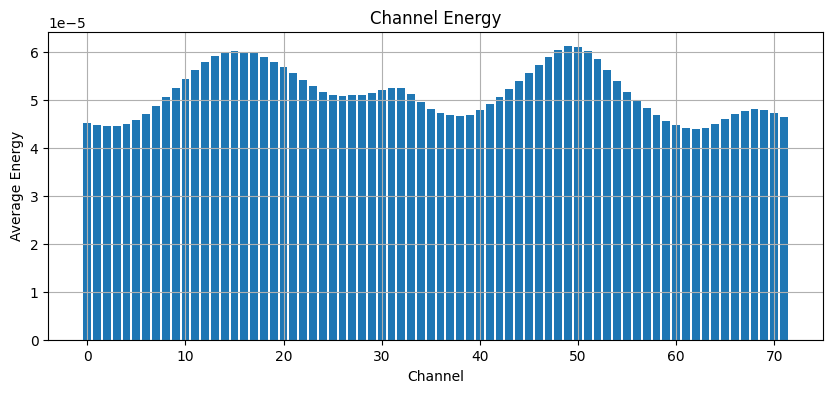

In [26]:
# ============================================================
# CHANNEL ENERGY
# ============================================================

energy = np.mean(

    np.abs(s21)**2,

    axis=(0,1)

)

plt.figure(figsize=(10,4))

plt.bar(

    np.arange(len(energy)),

    energy

)

plt.title("Channel Energy")

plt.xlabel("Channel")

plt.ylabel("Average Energy")

plt.grid(True)

plt.show()

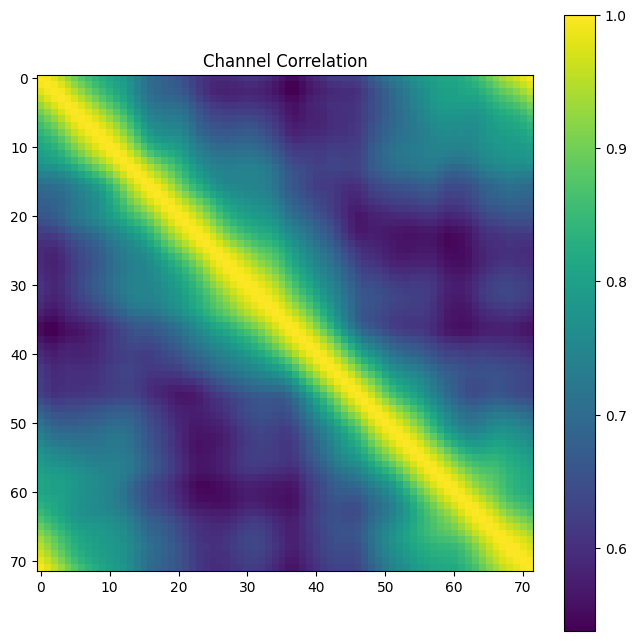

In [27]:
# ============================================================
# CHANNEL CORRELATION
# ============================================================

channel_mean = np.mean(

    np.abs(s21),

    axis=1

)

corr = np.corrcoef(

    channel_mean.T

)

plt.figure(figsize=(8,8))

plt.imshow(

    corr,

    cmap="viridis"

)

plt.title("Channel Correlation")

plt.colorbar()

plt.show()

In [28]:
# ============================================================
# DEAD CHANNEL CHECK
# ============================================================

threshold = energy.mean()*0.10

dead = np.where(

    energy<threshold

)[0]

print("Dead Channels")

print(dead)

print()

print("Count :",len(dead))

Dead Channels
[]

Count : 0


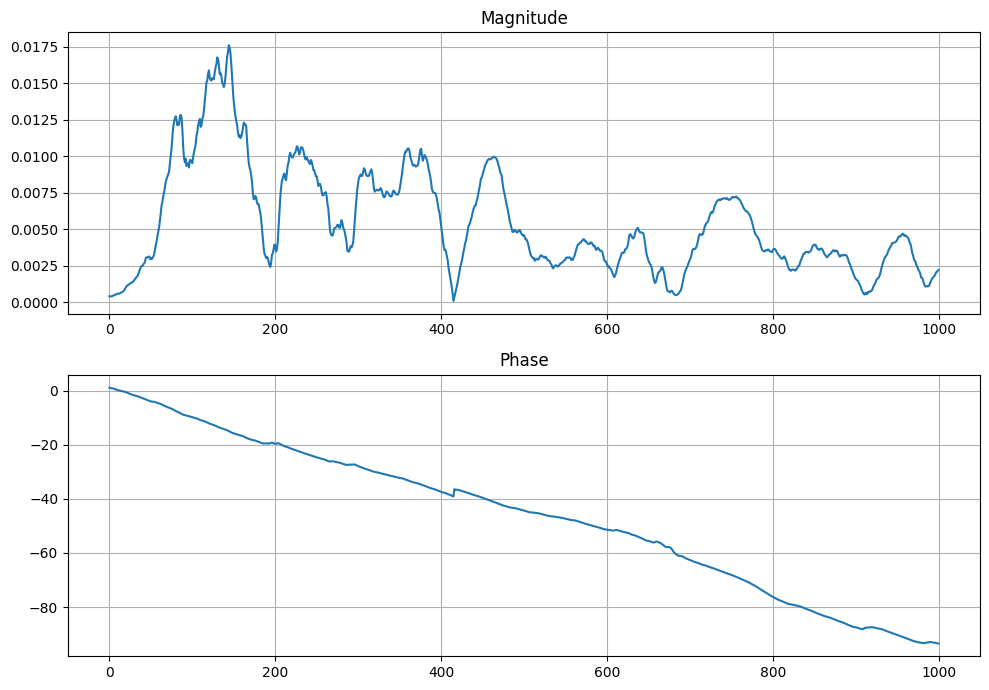

In [29]:
# ============================================================
# SINGLE SCAN VIEWER
# ============================================================

scan = 0
channel = 0

sig = s21[scan,:,channel]

fig,ax = plt.subplots(2,1,figsize=(10,7))

ax[0].plot(np.abs(sig))

ax[0].set_title("Magnitude")

ax[0].grid()

phase = np.unwrap(np.angle(sig))

ax[1].plot(phase)

ax[1].set_title("Phase")

ax[1].grid()

plt.tight_layout()

plt.show()

complex128
True


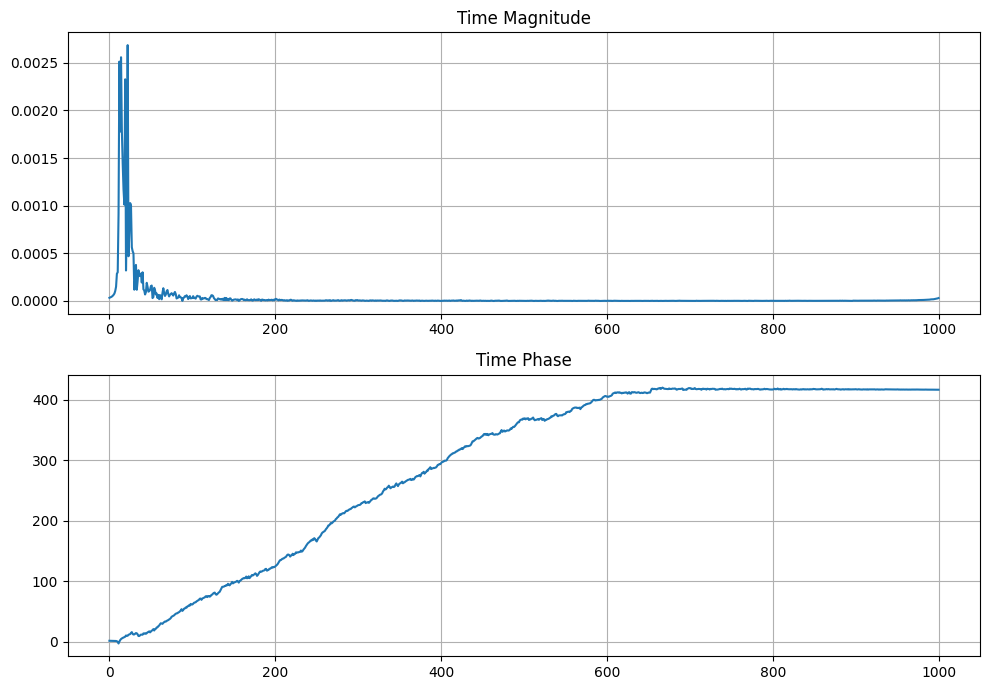

In [30]:
# ============================================================
# COMPLEX IFFT
# ============================================================

time_signal = ifft(

    s21,

    axis=1

)

print(time_signal.dtype)

print(np.iscomplexobj(time_signal))

scan = 0
channel = 0

fig,ax = plt.subplots(2,1,figsize=(10,7))

ax[0].plot(

    np.abs(time_signal[scan,:,channel])

)

ax[0].set_title("Time Magnitude")

ax[0].grid()

ax[1].plot(

    np.unwrap(

        np.angle(

            time_signal[scan,:,channel]

        )

    )

)

ax[1].set_title("Time Phase")

ax[1].grid()

plt.tight_layout()

plt.show()

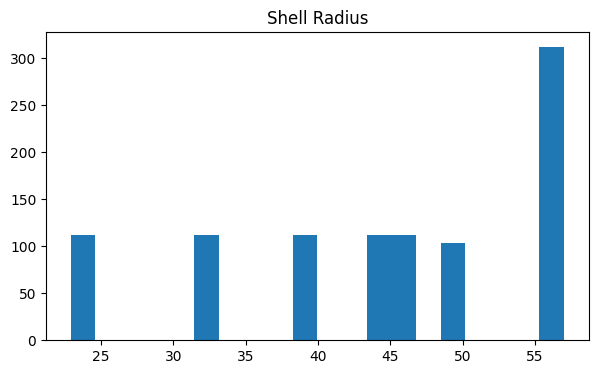

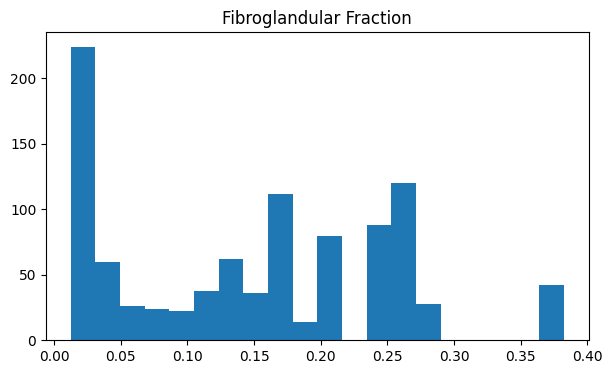

In [31]:
# ============================================================
# PHANTOM DISTRIBUTION
# ============================================================

plt.figure(figsize=(7,4))

physical["shell_radius"].hist(

    bins=20

)

plt.title("Shell Radius")

plt.grid()

plt.show()

plt.figure(figsize=(7,4))

physical["fib_percent"].hist(

    bins=20

)

plt.title("Fibroglandular Fraction")

plt.grid()

plt.show()

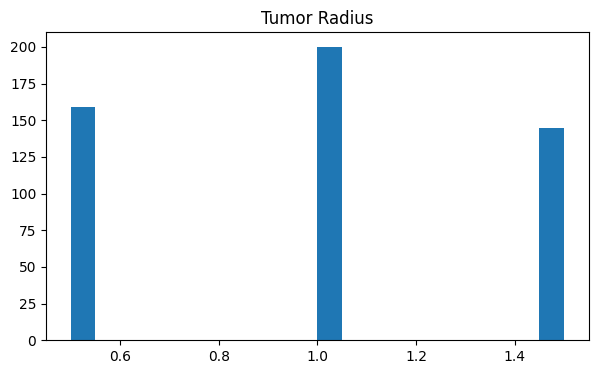

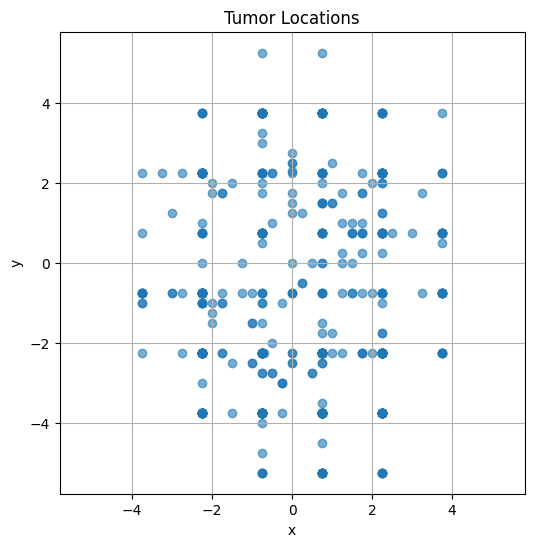

In [32]:
# ============================================================
# TUMOR DISTRIBUTION
# ============================================================

tumor = physical.dropna(

    subset=["tum_rad"]

)

plt.figure(figsize=(7,4))

tumor["tum_rad"].hist(

    bins=20

)

plt.title("Tumor Radius")

plt.grid()

plt.show()

plt.figure(figsize=(6,6))

plt.scatter(

    tumor["tum_x"],

    tumor["tum_y"],

    alpha=.6

)

plt.xlabel("x")

plt.ylabel("y")

plt.axis("equal")

plt.grid()

plt.title("Tumor Locations")

plt.show()

In [33]:
# ============================================================
# FINAL AUDIT REPORT
# ============================================================

print("="*65)

print("UM-BMID DATASET AUDIT V2")

print("="*65)

print()

print("Scans                :", s21.shape[0])

print("Frequency Samples    :", s21.shape[1])

print("Channels             :", s21.shape[2])

print()

print("Complex Dataset      :", np.iscomplexobj(s21))

print("Complex Time Signal  :", np.iscomplexobj(time_signal))

print()

print("Healthy              :", metadata["tum_rad"].isna().sum())

print("Tumor                :", metadata["tum_rad"].notna().sum())

print()

print("Merged Metadata      :", physical["shell_radius"].notna().sum())

print()

print("Dead Channels        :", len(dead))

print(dead)

print()

print("Recommended Pipeline")

print("-----------------------")

print("✓ TVSVD")

print("✓ Complex IFFT")

print("✓ Adaptive ε")

print("✓ Bent-Ray TOF")

print("✓ Complex Delay")

print("✓ Phase DMAS")

print("✓ MER")

print("✓ Contrast Refinement")

print("="*65)

UM-BMID DATASET AUDIT V2

Scans                : 505
Frequency Samples    : 1001
Channels             : 72

Complex Dataset      : True
Complex Time Signal  : True

Healthy              : 797
Tumor                : 504

Merged Metadata      : 976

Dead Channels        : 0
[]

Recommended Pipeline
-----------------------
✓ TVSVD
✓ Complex IFFT
✓ Adaptive ε
✓ Bent-Ray TOF
✓ Complex Delay
✓ Phase DMAS
✓ MER
✓ Contrast Refinement


In [34]:
missing = metadata[
    ~metadata["phant_id"].isin(phantom_db["phantom_id"])
]

print(missing["phant_id"].value_counts())

phant_id
        152
A3F1     18
A16      17
A15      17
A12      17
A14      16
A2       15
A1       15
A11      15
A3       15
A13      14
A2F3      8
A3F4      6
Name: count, dtype: int64
